In [1]:
print("test")

test


In [1]:
import sqlite3
import pandas as pd

In [2]:
conn= sqlite3.connect("C:\Pandoras_Box\Product_Management\Dev_Envs\Data_Engineering\ML\ML\PythonDataScienceHandbook\datacamp_python.db")

In [3]:
file = pd.read_csv("C:\Pandoras_Box\Product_Management\Dev_Envs\Data_Engineering\ML\ML\PythonDataScienceHandbook\covid_impact_on_airport_traffic.csv")
file

,AggregationMethod,Date,Version,AirportName,PercentOfBaseline,Centroid,City,State,ISO_3166_2,Country,Geography
0,Daily,2020-04-03,1,Kingsford Smith,64,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
1,Daily,2020-04-13,1,Kingsford Smith,29,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
2,Daily,2020-07-10,1,Kingsford Smith,54,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
3,Daily,2020-09-02,1,Kingsford Smith,18,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
4,Daily,2020-10-31,1,Kingsford Smith,22,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
...,...,...,...,...,...,...,...,...,...,...,...
7242,Daily,2020-06-05,1,Seattle-Tacoma International,80,POINT(-122.308661576118 47.4505828917119),SeaTac,Washington,US-WA,United States of America (the),"POLYGON((-122.297594547272 47.434474106872, -1..."
7243,Daily,2020-10-03,1,Seattle-Tacoma International,55,POINT(-122.308661576118 47.4505828917119),SeaTac,Washington,US-WA,United States of America (the),"POLYGON((-122.297594547272 47.434474106872, -1..."
7244,Daily,2020-07-16,1,Seattle-Tacoma International,76,POINT(-122.308661576118 47.4505828917119),SeaTac,Washington,US-WA,United States of America (the),"POLYGON((-122.297594547272 47.434474106872, -1..."
7245,Daily,2020-07-31,1,Seattle-Tacoma International,69,POINT(-122.308661576118 47.4505828917119),SeaTac,Washington,US-WA,United States of America (the),"POLYGON((-122.297594547272 47.434474106872, -1..."


In [4]:
file.to_sql(
            'airport',             # Name of the sql table
            conn,                 # sqlite.Connection or sqlalchemy.engine.Engine
            if_exists='replace'
           )

7247

In [5]:
cursor = conn.cursor()

cursor.execute("""SELECT Date, AirportName, PercentOfBaseline, Country
               FROM airport
               LIMIT 5""")
cursor.fetchone()

('2020-04-03', 'Kingsford Smith', 64, 'Australia')

In [13]:
query_one = ("""
            SELECT Date, AirportName, PercentOfBaseline
            FROM airport
            WHERE AirportName LIKE 'Charlotte%'""")


cursor.execute(query_one)
cursor.fetchall()

[('2020-07-23', 'Charlotte Douglas International', 100),
 ('2020-03-20', 'Charlotte Douglas International', 80),
 ('2020-07-30', 'Charlotte Douglas International', 89),
 ('2020-08-12', 'Charlotte Douglas International', 94),
 ('2020-05-06', 'Charlotte Douglas International', 74),
 ('2020-08-16', 'Charlotte Douglas International', 82),
 ('2020-09-07', 'Charlotte Douglas International', 34),
 ('2020-09-14', 'Charlotte Douglas International', 97),
 ('2020-09-15', 'Charlotte Douglas International', 99),
 ('2020-10-09', 'Charlotte Douglas International', 80),
 ('2020-11-09', 'Charlotte Douglas International', 79),
 ('2020-11-25', 'Charlotte Douglas International', 77),
 ('2020-11-29', 'Charlotte Douglas International', 74),
 ('2020-04-03', 'Charlotte Douglas International', 64),
 ('2020-09-10', 'Charlotte Douglas International', 100),
 ('2020-09-16', 'Charlotte Douglas International', 100),
 ('2020-10-01', 'Charlotte Douglas International', 96),
 ('2020-11-24', 'Charlotte Douglas Internatio

In [10]:
cursor.fetchall()

[('2020-04-13', 'Kingsford Smith', 29, 'Australia'),
 ('2020-07-10', 'Kingsford Smith', 54, 'Australia'),
 ('2020-09-02', 'Kingsford Smith', 18, 'Australia'),
 ('2020-10-31', 'Kingsford Smith', 22, 'Australia')]

In [11]:
cursor.execute("""
                CREATE TABLE studentinfo
                (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                name TEXT,
                subject TEXT
                )
                 """)

In [12]:
cursor.execute("""
               SELECT name
               FROM sqlite_master
               WHERE type='table'
               """)

cursor.fetchall()

[('airport',), ('studentinfo',), ('sqlite_sequence',)]

In [14]:
query = """
        INSERT INTO studentinfo
        (name, subject)
        VALUES (?,?)
        """

value = ("Kate", "Math")
cursor.execute(query, value)

In [24]:
query = """
           INSERT INTO studentinfo
           (name, subject)
           VALUES (?, ?)
        """

values = [("Lily", "Stat"),
          ("YP", "Math"),
          ("Ali","Data Science"),
          ("KP","Data Science")]

cursor.executemany(query,values)

In [25]:
cursor.execute("""
               SELECT name,subject
               FROM studentinfo
               """)
cursor.fetchall()

[('Kate', 'Math'),
 ('Lily', 'Stat'),
 ('YP', 'Math'),
 ('Ali', 'Data Science'),
 ('KP', 'Data Science')]

In [26]:
cursor.execute("""
                SELECT *
                FROM studentinfo
                WHERE subject LIKE 'Math'
                 """)
cursor.fetchall()

[(1, 'Kate', 'Math'), (3, 'YP', 'Math')]

In [14]:
conn.commit()

In [15]:
data_sql_1 = pd.read_sql("""
                        SELECT Date,City,PercentOfBaseline
                        FROM airport
                        WHERE PercentOfBaseline > 20
                        ORDER BY Date DESC
                        """,
                        conn)


print(data_sql_1.head())

         Date          City  PercentOfBaseline
0  2020-12-02        Sydney                 27
1  2020-12-02      Santiago                 48
2  2020-12-02       Calgary                 99
3  2020-12-02  Leduc County                100
4  2020-12-02      Richmond                 86


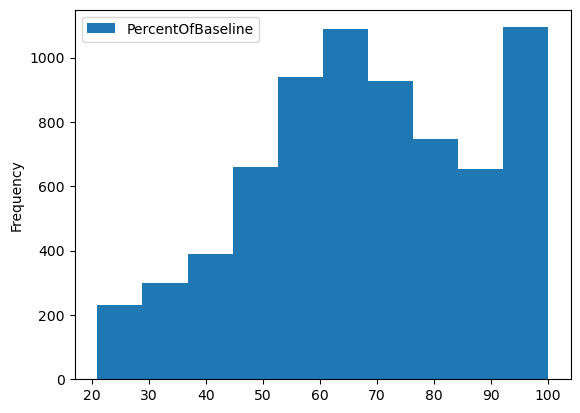

In [16]:
data_sql_1.plot(y="PercentOfBaseline",kind="hist");

In [1]:
import sqlalchemy as alchemy

In [2]:
alchemy

<module 'sqlalchemy' from 'c:\\Pandoras_Box\\Conda_Envs\\lib\\site-packages\\sqlalchemy\\__init__.py'>